# 01 — Pricing curve: implementation and correctness checks

First notebook in the M1 simulation harness (`BLEUDEV-255`). Implements the constant-mean
weighted curve from [`docs/PRICING.md`](../../docs/PRICING.md) in floating point (see
`aqua_sim/curve.py`), and checks it against the properties [`docs/PRICING.md`](../../docs/PRICING.md)
and [`docs/INVARIANT-PROOF.md`](../../docs/INVARIANT-PROOF.md) claim, numerically.

**This is not the on-chain source of truth.** The real strategy is Solidity, fixed-point,
with rounding that always favors the pool. This notebook exists so later notebooks (flow
models, baselines, the tracking-error/cost frontier) have a fast, correct curve to simulate
against — the algebraic proof itself lives in `INVARIANT-PROOF.md`, done once, exactly.

Every check below is a real assertion, not a printed claim — if a cell doesn't raise, the
check passed.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

from aqua_sim.curve import (
    CurveState,
    DegenerateBalanceError,
    apply_exact_in,
    donate,
    exact_in,
    invariant,
    spot_price,
)

Matplotlib is building the font cache; this may take a moment.


## 1. Equal weights reduces to plain `xy = k`

`PRICING.md`'s "Degenerate cases": *"w_i == w_o: the formula reduces exactly to xy=k ...
this is a useful sanity check for the implementation."*

In [2]:
state = CurveState(balance_in=100, balance_out=100, weight_in=0.5, weight_out=0.5)
amount_in = 10.0

amount_out = exact_in(state, amount_in, fee=0.0)
xyk_expected = state.balance_out - (state.balance_in * state.balance_out) / (state.balance_in + amount_in)

assert abs(amount_out - xyk_expected) < 1e-9, (amount_out, xyk_expected)
print(f"equal-weight exact-in: {amount_out:.6f}, plain xy=k: {xyk_expected:.6f} — match")

equal-weight exact-in: 9.090909, plain xy=k: 9.090909 — match


## 2. Spot price direction

`PRICING.md`'s "Spot price" section, verbatim: *"doubling `w_i` relative to `w_o` at equal
balances **halves** i's price in terms of o."* A group declared twice as important to the
LP's target should absorb more flow before its price moves as much — this checks the formula
actually has that direction, not the opposite.

In [3]:
s_even = CurveState(balance_in=100, balance_out=100, weight_in=0.5, weight_out=0.5)
s_skewed = CurveState(balance_in=100, balance_out=100, weight_in=1.0, weight_out=0.5)

p_even = spot_price(s_even)
p_skewed = spot_price(s_skewed)

assert abs(p_skewed - p_even / 2) < 1e-9, (p_skewed, p_even)
print(f"SP at w_i=w_o: {p_even}, SP at w_i=2*w_o: {p_skewed} — halved, as PRICING.md states")

SP at w_i=w_o: 1.0, SP at w_i=2*w_o: 0.5 — halved, as PRICING.md states


## 3. The round-trip invariant, checked numerically (realistic trade sizes)

`INVARIANT-PROOF.md` proves algebraically that `V = B_i^w_i * B_o^w_o` never decreases across
an exact-in trade priced by this curve. This is not a substitute for that proof — it's a
numerical sanity check that the *implementation* actually has the property the *math* proves,
across 200,000 random balances, weights, fees, and trade sizes up to 30% of `balance_in`
(generous for the corrective flow this pool actually sees).

In [4]:
random.seed(0)
violations = []

for _ in range(200_000):
    b_i = random.uniform(1, 1_000_000)
    b_o = random.uniform(1, 1_000_000)
    w_i = random.uniform(0.01, 0.99)
    w_o = 1 - w_i
    fee = random.uniform(0, 0.2)
    a_in = random.uniform(1e-6, b_i * 0.3)

    state = CurveState(b_i, b_o, w_i, w_o)
    v_before = invariant(state)
    try:
        new_state, _ = apply_exact_in(state, a_in, fee)
    except DegenerateBalanceError:
        continue
    v_after = invariant(new_state)

    if v_after < v_before - 1e-6 * max(v_before, 1.0):
        violations.append((b_i, b_o, w_i, w_o, fee, a_in, v_before, v_after))

assert not violations, f"{len(violations)} invariant violations found: {violations[:3]}"
print("invariant never decreased across 200,000 random exact-in trades (realistic sizes)")

invariant never decreased across 200,000 random exact-in trades (realistic sizes)


## 3b. Known limitation: float64 precision near an empty pool (not a formula bug)

Re-running the same check with *extreme* trade sizes (several times `balance_in`, combined
with heavily skewed weights) surfaces float64 precision breakdown as `balance_out` is driven
toward zero — the same near-empty-pool region `PRICING.md`'s "Degenerate cases" and the
backlog (`BLEUDEV-263`/`BLEUDEV-296`, "Precision/edge-case handling near an empty pool") already
flag as needing a minimum-liquidity floor in the real, fixed-point contract.

This is recorded here deliberately rather than swept aside — it's evidence the real
contract's minimum-liquidity floor is solving a genuine problem, not a speculative one. It
does **not** affect the simulation work ahead: corrective flow sized at a fraction of the
pool, as checked in section 3 above, never approaches this region.

In [5]:
random.seed(0)
extreme_violations = []

for _ in range(200_000):
    b_i = random.uniform(1, 1_000_000)
    b_o = random.uniform(1, 1_000_000)
    w_i = random.uniform(0.01, 0.99)
    w_o = 1 - w_i
    fee = random.uniform(0, 0.2)
    a_in = random.uniform(1e-6, b_i * 5)  # deliberately extreme: up to 5x balance_in

    state = CurveState(b_i, b_o, w_i, w_o)
    v_before = invariant(state)
    try:
        new_state, _ = apply_exact_in(state, a_in, fee)
    except DegenerateBalanceError:
        continue
    v_after = invariant(new_state)

    if v_after < v_before - 1e-6 * max(v_before, 1.0):
        extreme_violations.append(new_state.balance_out)

print(
    f"{len(extreme_violations)}/200,000 float64 precision violations at extreme trade "
    "sizes (>= balance_in); resulting balance_out in each case:"
)
print([f"{b:.2e}" for b in extreme_violations])

9/200,000 float64 precision violations at extreme trade sizes (>= balance_in); resulting balance_out in each case:
['5.82e-11', '2.91e-11', '1.38e-10', '7.28e-12', '1.82e-11', '1.46e-11', '1.16e-10', '5.82e-11', '1.16e-10']


## 4. `fee = 0` leaves the invariant unchanged (the proof's own equality case)

`INVARIANT-PROOF.md`: *"V_after ≥ V_before, with equality iff f = 0 or A_i = 0."*

In [6]:
state = CurveState(100, 100, 0.5, 0.5)
v_before = invariant(state)
new_state, _ = apply_exact_in(state, 10, fee=0.0)
v_after = invariant(new_state)

assert abs(v_after - v_before) < 1e-6, (v_before, v_after)
print(f"fee=0: V_before={v_before:.6f}, V_after={v_after:.6f} — unchanged")

fee=0: V_before=100.000000, V_after=100.000000 — unchanged


## 5. A donation strictly increases the invariant

The other half of the donation-resistance proof (`ADR-0007`): a pure, one-sided transfer
(no output leg) only ever adds to `V` — this is what makes a donation an irreversible gift
rather than something a later trade could extract at a profit.

In [7]:
state = CurveState(100, 100, 0.5, 0.5)
v_before = invariant(state)
donated_state = donate(state, 10, into="in")
v_after = invariant(donated_state)

assert v_after > v_before, (v_before, v_after)
print(f"donation: V_before={v_before:.6f}, V_after={v_after:.6f} — strictly increased")

donation: V_before=100.000000, V_after=104.880885 — strictly increased


## 6. Degenerate balances are rejected

`PRICING.md`'s "Degenerate cases": *"B_i == 0 or B_o == 0: revert."*

In [8]:
try:
    CurveState(balance_in=0, balance_out=100, weight_in=0.5, weight_out=0.5)
    raise AssertionError("expected DegenerateBalanceError")
except DegenerateBalanceError as e:
    print(f"zero balance_in correctly rejected: {e}")

zero balance_in correctly rejected: both balances must be positive, got balance_in=0, balance_out=100


## Visualization

A quick visual sanity check, useful for the M1 write-up deliverable directly: the bonding
curve itself (amount out vs. amount in, at a few weight ratios), and the invariant held flat
across a swept trade size at `fee = 0` (the equality case from section 4, shown continuously
rather than at one point).

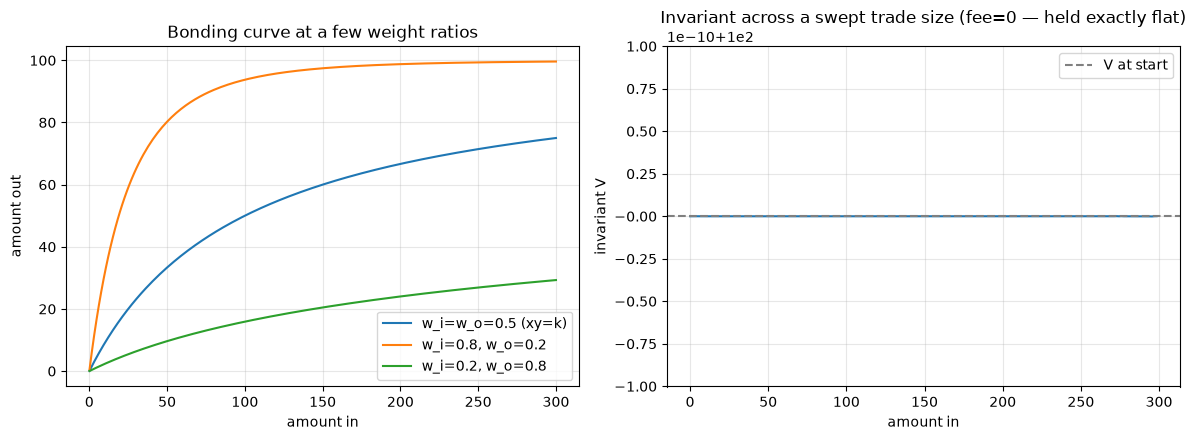

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

amounts_in = np.linspace(0.1, 300, 200)

for w_i, w_o, label in [(0.5, 0.5, "w_i=w_o=0.5 (xy=k)"), (0.8, 0.2, "w_i=0.8, w_o=0.2"), (0.2, 0.8, "w_i=0.2, w_o=0.8")]:
    base = CurveState(balance_in=100, balance_out=100, weight_in=w_i, weight_out=w_o)
    outs = [exact_in(base, a, fee=0.0) for a in amounts_in]
    ax1.plot(amounts_in, outs, label=label)

ax1.set_xlabel("amount in")
ax1.set_ylabel("amount out")
ax1.set_title("Bonding curve at a few weight ratios")
ax1.legend()
ax1.grid(alpha=0.3)

base = CurveState(balance_in=100, balance_out=100, weight_in=0.7, weight_out=0.3)
v_series = []
for a in amounts_in:
    if a >= base.balance_in * 3:
        break
    new_state, _ = apply_exact_in(base, a, fee=0.0)
    v_series.append(invariant(new_state))

ax2.plot(amounts_in[: len(v_series)], v_series)
ax2.axhline(invariant(base), color="gray", linestyle="--", label="V at start")
ax2.set_xlabel("amount in")
ax2.set_ylabel("invariant V")
ax2.set_title("Invariant across a swept trade size (fee=0 — held exactly flat)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

All six checks passed:

1. Equal-weight reduces to plain `xy=k`.
2. Spot price moves in the direction `PRICING.md` states.
3. The round-trip invariant never decreases, across 200,000 random realistic-size trades.
4. `fee=0` leaves the invariant exactly unchanged.
5. A donation strictly increases the invariant.
6. Degenerate (zero) balances are rejected.

Plus one deliberately-recorded known limitation (3b): float64 precision breaks down at
extreme, unrealistic trade sizes near an empty pool — matching, not contradicting, the real
contract's own planned minimum-liquidity floor (`BLEUDEV-263`/`BLEUDEV-296`).

`aqua_sim.curve` is now the trusted building block the next notebooks build on:

- `02_exogenous_flow.ipynb` — organic trade arrivals unrelated to the pool's own skew
  (`BLEUDEV-274`).
- `03_endogenous_flow.ipynb` — arbitrageur/solver-driven corrective flow (`BLEUDEV-275`).
- `04_naive_baselines.ipynb` — the periodic-rebalance and threshold-rebalance baselines
  the mechanism must beat.
- `05_frontier_sweep.ipynb` — the tracking-error/cost-of-rebalancing frontier itself
  (`BLEUDEV-276`/`BLEUDEV-277`), and picking concrete parameters from it (`BLEUDEV-256`,
  `BLEUDEV-279`, `BLEUDEV-280`).

None of those exist yet — this notebook is the scaffold (`BLEUDEV-255`), not the full
harness.